In [3]:
!wget -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task

--2026-09-15 09:36:14--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.98.207, 74.125.135.207, 74.125.142.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5777746 (5.5M) [application/octet-stream]
Saving to: ‘pose_landmarker.task’

pose_landmarker.tas 100%[===================>]   5.51M  --.-KB/s    in 0.02s   

2026-09-15 09:36:15 (231 MB/s) - ‘pose_landmarker.task’ saved [5777746/5777746]



In [8]:
!pip install mediapipe gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import glob
import numpy as np
import os
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Dataset/Real Life Violence Dataset'
total_videos = 0
video_extensions = ('.mp4', '.avi', '.mkv', '.mov')

# Kiểm tra xem đường dẫn có tồn tại không
if not os.path.exists(DATASET_DIR):
    print(" Không tìm thấy đường dẫn! Bạn hãy kiểm tra lại tên thư mục.")
else:
    # Duyệt qua toàn bộ thư mục và thư mục con
    for dirpath, dirnames, filenames in os.walk(DATASET_DIR):

        # Lọc ra các file là video
        video_files = [f for f in filenames if f.lower().endswith(video_extensions)]

        # Chỉ in ra những thư mục có chứa video
        if len(video_files) > 0:

            level = dirpath.replace(DATASET_DIR, '').count(os.sep)
            indent = ' ' * 4 * level
            folder_name = os.path.basename(dirpath)
            if folder_name == "":
                folder_name = "Thư mục gốc"

            print(f"{indent}Nhãn/Thư mục: {folder_name} (chứa {len(video_files)} video)")

            sub_indent = ' ' * 4 * (level + 1)
            for video in video_files[:3]:
                print(f"{sub_indent}├──  {video}")

            if len(video_files) > 3:
                print(f"{sub_indent}└── ... (và {len(video_files) - 3} file khác)")

            print(f"{indent}")
            total_videos += len(video_files)

    print("-" * 50)
    print(f"TỔNG KẾT: Đã tìm thấy tổng cộng {total_videos} video trong dataset.")

    Nhãn/Thư mục: NonViolence (chứa 1000 video)
        ├──  NV_110.mp4
        ├──  NV_117.mp4
        ├──  NV_156.mp4
        └── ... (và 997 file khác)
    
    Nhãn/Thư mục: Violence (chứa 1001 video)
        ├──  V_130.mp4
        ├──  V_118.mp4
        ├──  V_139.mp4
        └── ... (và 998 file khác)
    
--------------------------------------------------
TỔNG KẾT: Đã tìm thấy tổng cộng 2001 video trong dataset.


In [ ]:
data = []
labels = ['NonViolence', 'Violence']

for label in labels:
    folder_path = os.path.join(DATASET_DIR, label)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.mp4', '.avi', '.mkv', '.mov')):
                file_path = os.path.join(folder_path, file)
                label_idx = 0 if label == 'NonViolence' else 1
                data.append({'file_path': file_path, 'label_name': label, 'label_idx': label_idx})

# Chuyển thành DataFrame (bảng dữ liệu) để dễ xử lý
df = pd.DataFrame(data)
print(f"Tổng số video đọc được: {len(df)}")

# Tách 70% cho Train (1400 video), 30% còn lại (600 video) cho Val & Test
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label_idx'])

# chia đôi phần 30% kia (600 video) thành 300 Val (50%) và 300 Test (50%)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label_idx'])

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

# Gộp lại và lưu ra file CSV
final_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

csv_path = os.path.join(DATASET_DIR, 'dataset_split.csv')
final_df.to_csv(csv_path, index=False)

print("-" * 40)
print("\nBẢNG THỐNG KÊ SỐ LƯỢNG SAU KHI CHIA:")
print("Tập TRAIN (Huấn luyện):", len(train_df))
print("Tập VAL (Kiểm định):  ", len(val_df))
print("Tập TEST (Kiểm tra):  ", len(test_df))
print("-" * 40)

print("\nXem thử 5 dòng dữ liệu chuẩn bị đưa vào mô hình:")
display(final_df.head())

Tổng số video đọc được: 2001
----------------------------------------

BẢNG THỐNG KÊ SỐ LƯỢNG SAU KHI CHIA:
Tập TRAIN (Huấn luyện): 1400
Tập VAL (Kiểm định):   300
Tập TEST (Kiểm tra):   301
----------------------------------------

Xem thử 5 dòng dữ liệu chuẩn bị đưa vào mô hình:


,file_path,label_name,label_idx,split
0,/content/drive/MyDrive/Đồ án chuyên ngành...,NonViolence,0,train
1,/content/drive/MyDrive/Đồ án chuyên ngành...,Violence,1,train
2,/content/drive/MyDrive/Đồ án chuyên ngành...,Violence,1,train
3,/content/drive/MyDrive/Đồ án chuyên ngành...,Violence,1,train
4,/content/drive/MyDrive/Đồ án chuyên ngành...,Violence,1,train


In [ ]:
import os
import math
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf

class VideoClipDataGenerator(tf.keras.utils.Sequence):
    """
    Generator tự động phân tích và lưu/tải cache danh sách clip 5s từ Google Drive.
    """
    def __init__(self, df, batch_size=8, clip_duration=5, fps_extracted=15,
                 image_size=(224, 224), shuffle=True, cache_path=None):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.clip_duration = clip_duration
        self.fps_extracted = fps_extracted
        self.sequence_length = self.clip_duration * self.fps_extracted  # 75 frames
        self.image_size = image_size
        self.shuffle = shuffle
        self.cache_path = cache_path

        # 1. Tải từ Drive nếu đã có file Cache, nếu chưa thì phân tích và lưu mới
        self.clips_list = self._get_or_create_clips()
        self.indices = np.arange(len(self.clips_list))
        self.on_epoch_end()

    def _get_or_create_clips(self):
        # Nếu đã có file cache trên Drive -> Tải trực tiếp (mất 1-2 giây)
        if self.cache_path and os.path.exists(self.cache_path):
            print(f"Đã tìm thấy Cache trên Drive! Đang tải dữ liệu từ: {self.cache_path}")
            cache_df = pd.read_csv(self.cache_path)
            return cache_df.to_dict('records')

        # Nếu chưa có file cache -> Phân tích độ dài từng video
        print("Chưa có file Cache. Đang phân tích độ dài các video để chia thành clip 5s...")
        clips = []
        for _, row in self.df.iterrows():
            video_path = row['file_path']
            label_idx = row['label_idx']

            cap = cv2.VideoCapture(video_path)
            fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()

            if fps == 0 or np.isnan(fps):
                fps = 30.0

            clip_frames = int(fps * self.clip_duration)
            num_clips = max(1, total_frames // clip_frames)

            for i in range(num_clips):
                start_frame = i * clip_frames
                clips.append({
                    'file_path': video_path,
                    'label_idx': label_idx,
                    'start_frame': start_frame,
                    'clip_frames': clip_frames
                })

        print(f"Tạo thành công {len(clips)} clip (mỗi clip dài 5s) từ {len(self.df)} video!")

        # Tự động tạo thư mục và lưu file Cache lên Drive
        if self.cache_path:
            os.makedirs(os.path.dirname(self.cache_path), exist_ok=True)
            pd.DataFrame(clips).to_csv(self.cache_path, index=False)
            print(f"Đã lưu file Cache thành công tại Drive: {self.cache_path}")

        return clips

    def __len__(self):
        return math.ceil(len(self.clips_list) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]

        X = []
        y = []

        for idx in batch_indices:
            clip_info = self.clips_list[idx]
            frames = self._extract_frames_from_clip(clip_info)
            X.append(frames)
            y.append(clip_info['label_idx'])

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _extract_frames_from_clip(self, clip_info):
        cap = cv2.VideoCapture(clip_info['file_path'])
        start_frame = int(clip_info['start_frame'])
        clip_frames = int(clip_info['clip_frames'])

        step = clip_frames / self.sequence_length

        frames = []
        for i in range(self.sequence_length):
            target_frame = int(start_frame + (i * step))
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            success, frame = cap.read()

            if success:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, self.image_size)
                frame = frame / 255.0
                frames.append(frame)
            else:
                break

        cap.release()

        while len(frames) < self.sequence_length:
            if len(frames) > 0:
                frames.append(frames[-1])
            else:
                frames.append(np.zeros((*self.image_size, 3), dtype=np.float32))

        return np.array(frames, dtype=np.float32)

In [ ]:
CACHE_DIR = "/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/clips"

BATCH_SIZE = 8
CLIP_DURATION = 5
FPS_EXTRACTED = 15
SEQUENCE_LENGTH = CLIP_DURATION * FPS_EXTRACTED
IMAGE_SIZE = (224, 224)

# 1. Khởi tạo Generator tập Train
train_generator = VideoClipDataGenerator(
    train_df,
    batch_size=BATCH_SIZE,
    clip_duration=CLIP_DURATION,
    fps_extracted=FPS_EXTRACTED,
    image_size=IMAGE_SIZE,
    shuffle=True,
    cache_path=f"{CACHE_DIR}/train_clips_5s.csv"
)

# 2. Khởi tạo Generator tập Validation
val_generator = VideoClipDataGenerator(
    val_df,
    batch_size=BATCH_SIZE,
    clip_duration=CLIP_DURATION,
    fps_extracted=FPS_EXTRACTED,
    image_size=IMAGE_SIZE,
    shuffle=False,
    cache_path=f"{CACHE_DIR}/val_clips_5s.csv"
)

# 3. Khởi tạo Generator tập Test
test_generator = VideoClipDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    clip_duration=CLIP_DURATION,
    fps_extracted=FPS_EXTRACTED,
    image_size=IMAGE_SIZE,
    shuffle=False,
    cache_path=f"{CACHE_DIR}/test_clips_5s.csv"
)

# In kiểm tra batch đầu tiên
x_batch, y_batch = train_generator[0]


Đã tìm thấy Cache trên Drive! Đang tải dữ liệu từ: /content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/clips/train_clips_5s.csv
Đã tìm thấy Cache trên Drive! Đang tải dữ liệu từ: /content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/clips/val_clips_5s.csv
Đã tìm thấy Cache trên Drive! Đang tải dữ liệu từ: /content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/clips/test_clips_5s.csv


In [ ]:
# 2. Kiểm tra thử 1 batch dữ liệu đầu ra
sample_X, sample_y = train_generator[0]

print(f"Đã khởi tạo Generator thành công!")
print(f"Kích thước 1 Batch ảnh (X): {sample_X.shape}  -> (Batch_size, Frames, Height, Width, Channels)")
print(f"Kích thước 1 Batch nhãn (y): {sample_y.shape}")
print(f"Tổng số batches tập Train: {len(train_generator)}")
print(f"Tổng số batches tập Val:   {len(val_generator)}")
print(f"Tổng số batches tập Test:  {len(test_generator)}")

Đã khởi tạo Generator thành công!
Kích thước 1 Batch ảnh (X): (8, 75, 224, 224, 3)  -> (Batch_size, Frames, Height, Width, Channels)
Kích thước 1 Batch nhãn (y): (8,)
Tổng số batches tập Train: 192
Tổng số batches tập Val:   38
Tổng số batches tập Test:  38


In [ ]:
import random
import matplotlib.pyplot as plt

#Chọn ngẫu nhiên 1 batch bất kỳ từ train_generator
random_batch_idx = random.randint(0, len(train_generator) - 1)
X_batch, y_batch = train_generator[random_batch_idx]

#Chọn ngẫu nhiên 1 video trong batch vừa lấy
random_video_idx = random.randint(0, len(X_batch) - 1)
sample_video_frames = X_batch[random_video_idx]
sample_video_label = y_batch[random_video_idx]

label_name = "Violence (Bạo lực)" if sample_video_label == 1 else "NonViolence (Bình thường)"

print(f"Chọn ngẫu nhiên: Batch {random_batch_idx + 1}/{len(train_generator)} | Video vị trí số {random_video_idx + 1}")
print(f"Nhãn video: {label_name}")
print(f"Kích thước video: {sample_video_frames.shape}\n")

# Hiển thị frames (5 hàng x 15 cột - mỗi hàng tượng trưng cho 1 giây)
num_frames = sample_video_frames.shape[0]  # 75 frames
fig, axes = plt.subplots(5, 15, figsize=(25, 10))

for i in range(num_frames):
    row = i // 15
    col = i % 15
    axes[row, col].imshow(sample_video_frames[i])
    axes[row, col].axis('off')
    axes[row, col].set_title(f"F{i+1}", fontsize=8)

plt.suptitle(f"75 Frames trích xuất ngẫu nhiên | Nhãn: {label_name}", fontsize=16)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)
detector = vision.PoseLandmarker.create_from_options(options)

POSE_SAVE_DIR = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints'

def extract_and_save_mediapipe_pose_resumable(generator, split_name, save_dir=POSE_SAVE_DIR):
    split_dir = os.path.join(save_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    final_file = os.path.join(split_dir, f"{split_name}_pose.npy")
    backup_file = os.path.join(split_dir, f"{split_name}_pose_backup.npy")

    if os.path.exists(final_file):
        print(f"Tập {split_name.upper()} đã hoàn thành 100%! Bỏ qua.")
        return

    all_poses = []
    start_idx = 0
    total_clips = len(generator.clips_list)

    if os.path.exists(backup_file):
        print(f"Tìm thấy bản lưu dở của {split_name.upper()}. Đang nạp dữ liệu cũ...")
        all_poses = np.load(backup_file).tolist()
        start_idx = len(all_poses)
        print(f"Bắt đầu chạy tiếp từ clip thứ {start_idx + 1}/{total_clips}")

    for idx in tqdm(range(start_idx, total_clips), desc=f"Xử lý {split_name}", initial=start_idx, total=total_clips):
        clip_info = generator.clips_list[idx]
        cap = cv2.VideoCapture(clip_info['file_path'])

        start_frame = int(clip_info['start_frame'])
        clip_frames = int(clip_info['clip_frames'])
        step = clip_frames / generator.sequence_length

        clip_poses = []
        for i in range(generator.sequence_length):
            target_frame = int(start_frame + (i * step))
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            success, frame = cap.read()
            frame_keypoints = np.zeros(132, dtype=np.float32)

            if success:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                # Chuyển đổi định dạng ảnh cho Tasks API
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                results = detector.detect(mp_image)

                if results.pose_landmarks and len(results.pose_landmarks) > 0:
                    kp_list = []
                    for landmark in results.pose_landmarks[0]:
                        kp_list.extend([landmark.x, landmark.y, landmark.z, getattr(landmark, 'visibility', 0.0)])
                    frame_keypoints = np.array(kp_list, dtype=np.float32)

            clip_poses.append(frame_keypoints)
        cap.release()

        while len(clip_poses) < generator.sequence_length:
            clip_poses.append(np.zeros(132, dtype=np.float32))

        all_poses.append(clip_poses)

        if (idx + 1) % 200 == 0:
            os.makedirs(split_dir, exist_ok=True)
            np.save(backup_file, np.array(all_poses, dtype=np.float32))

    os.makedirs(split_dir, exist_ok=True)
    np.save(final_file, np.array(all_poses, dtype=np.float32))
    if os.path.exists(backup_file):
        os.remove(backup_file)
    print(f"Lưu tập {split_name.upper()} thành công! Kích thước: {np.array(all_poses).shape}")

# Chạy trích xuất Pose Keypoints
print("Bắt đầu trích xuất Pose Keypoints")
extract_and_save_mediapipe_pose_resumable(train_generator, 'train')
extract_and_save_mediapipe_pose_resumable(val_generator, 'val')
extract_and_save_mediapipe_pose_resumable(test_generator, 'test')

Bắt đầu trích xuất Pose Keypoints
Tập TRAIN đã hoàn thành 100%! Bỏ qua.
Tập VAL đã hoàn thành 100%! Bỏ qua.
Tập TEST đã hoàn thành 100%! Bỏ qua.


In [ ]:
POSE_SAVE_DIR = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints'
splits = ['train', 'val', 'test']

print("KIỂM TRA KẾT QUẢ TRÍCH XUẤT POSE KEYPOINTS :\n" + "="*60)

for split in splits:
    file_path = os.path.join(POSE_SAVE_DIR, split, f"{split}_pose.npy")
    if os.path.exists(file_path):
        data = np.load(file_path)
        print(f"Tập {split.upper():<5} | Kích thước mảng: {data.shape}")
        print(f"Tổng số clips: {data.shape[0]} | Frames/clip: {data.shape[1]} | Vector Pose: {data.shape[2]}")
    else:
        print(f"Tập {split.upper():<5} | Chưa hoàn thành hoặc chưa có file trên Drive.")

print("="*60)

KIỂM TRA KẾT QUẢ TRÍCH XUẤT POSE KEYPOINTS :
Tập TRAIN | Kích thước mảng: (1535, 75, 132)
Tổng số clips: 1535 | Frames/clip: 75 | Vector Pose: 132
Tập VAL   | Kích thước mảng: (300, 75, 132)
Tổng số clips: 300 | Frames/clip: 75 | Vector Pose: 132
Tập TEST  | Kích thước mảng: (302, 75, 132)
Tổng số clips: 302 | Frames/clip: 75 | Vector Pose: 132


In [ ]:
import numpy as np
import tensorflow as tf
import os

class PoseOnlyDataGenerator(tf.keras.utils.Sequence):
    """
    Generator CHỈ sử dụng tọa độ khung xương (Pose Keypoints) từ file .npy,
    bỏ hoàn toàn ảnh RGB để tối ưu tốc độ huấn luyện.
    """
    def __init__(self, base_generator, pose_npy_path):
        self.base_gen = base_generator
        # Load toàn bộ ma trận pose vào RAM 1 lần duy nhất
        self.poses = np.load(pose_npy_path)

    def __len__(self):
        return len(self.base_gen)

    def __getitem__(self, index):
        # Lấy danh sách chỉ mục cho batch hiện tại
        batch_indices = self.base_gen.indices[index * self.base_gen.batch_size : (index + 1) * self.base_gen.batch_size]

        # 1. Lấy vector Pose tương ứng
        X_pose = self.poses[batch_indices]

        # 2. Lấy trực tiếp nhãn y từ clips_list (KHÔNG gọi self.base_gen[index] để tránh đọc lại video RGB)
        y = np.array([self.base_gen.clips_list[i]['label_idx'] for i in batch_indices], dtype=np.int32)

        return X_pose, y

    def on_epoch_end(self):
        self.base_gen.on_epoch_end()

# Đường dẫn thư mục lưu Pose 5s trên Drive
POSE_DIR = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints'

print(" Đang tải dữ liệu Pose lên bộ nhớ...")
train_pose_gen = PoseOnlyDataGenerator(train_generator, os.path.join(POSE_DIR, "train/train_pose.npy"))
val_pose_gen   = PoseOnlyDataGenerator(val_generator, os.path.join(POSE_DIR, "val/val_pose.npy"))
test_pose_gen  = PoseOnlyDataGenerator(test_generator, os.path.join(POSE_DIR, "test/test_pose.npy"))

sample_X, sample_y = train_pose_gen[0]
print(f"Hoàn tất! Kích thước 1 Batch đầu vào: {sample_X.shape} -> (Batch Size, 75 Frames, 132 Điểm)")

 Đang tải dữ liệu Pose lên bộ nhớ...
Hoàn tất! Kích thước 1 Batch đầu vào: (8, 75, 132) -> (Batch Size, 75 Frames, 132 Điểm)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.regularizers import l2

def build_bilstm_model(seq_len=75, num_features=132):
    model = Sequential([
        Input(shape=(seq_len, num_features), name='pose_input'),
        # Đã bỏ Masking layer để tương thích 100% với cuDNN GPU và không mất tọa độ hông (0.0)

        # Lớp BiLSTM
        Bidirectional(
            LSTM(64, return_sequences=False, dropout=0.3),
            name='bilstm_main'
        ),
        Dropout(0.4, name='dropout_1'),

        # Lớp Dense
        Dense(32, activation='relu', kernel_regularizer=l2(0.01), name='dense_features'),
        Dropout(0.3, name='dropout_2'),

        Dense(1, activation='sigmoid', name='output_layer')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Khởi tạo lại mô hình
model = build_bilstm_model(seq_len=75, num_features=132)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bilstm_main (Bidirectional)     │ (None, 128)            │       100,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,025 (410.25 KB)

 Trainable params: 105,025 (410.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Thêm tên file cụ thể
X_train = np.load('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints/train/train_pose.npy')
X_val   = np.load('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints/val/val_pose.npy')
X_test  = np.load('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints/test/test_pose.npy')



In [ ]:
import numpy as np

def normalize_pose_to_hip_center(X):
    """
    Hàm dịch chuyển toàn bộ tọa độ khung xương về gốc tâm hông (Mid-Hip).
    Giúp mô hình nhận diện hành động bất kể người đứng ở vị trí nào trong video.
    """
    X_norm = X.copy()
    N, T, F = X_norm.shape  # T tự động nhận 75 frames

    # Reshape về dạng (Số clips, T frames, 33 khớp, 4 thuộc tính x,y,z,v)
    X_reshaped = X_norm.reshape(N, T, 33, 4)

    # Tọa độ tâm hông = Trung bình giữa Hông trái (Landmark 23) và Hông phải (Landmark 24)
    hip_x = (X_reshaped[:, :, 23, 0] + X_reshaped[:, :, 24, 0]) / 2.0
    hip_y = (X_reshaped[:, :, 23, 1] + X_reshaped[:, :, 24, 1]) / 2.0

    # Trừ tọa độ tâm hông để đưa hông về gốc (0, 0)
    X_reshaped[:, :, :, 0] -= np.expand_dims(hip_x, axis=-1)
    X_reshaped[:, :, :, 1] -= np.expand_dims(hip_y, axis=-1)

    # Reshape lại về dạng ban đầu (N, T, 132)
    return X_reshaped.reshape(N, T, F)

print("Đang chuẩn hóa tọa độ về gốc tâm hông (Mid-Hip)...")

# Áp dụng chuẩn hóa trực tiếp vào thuộc tính .poses của các Pose Generator
train_pose_gen.poses = normalize_pose_to_hip_center(train_pose_gen.poses)
val_pose_gen.poses   = normalize_pose_to_hip_center(val_pose_gen.poses)
test_pose_gen.poses  = normalize_pose_to_hip_center(test_pose_gen.poses)

print(f"Hoàn tất chuẩn hóa! Kích thước mảng Train mới: {train_pose_gen.poses.shape}")

Đang chuẩn hóa tọa độ về gốc tâm hông (Mid-Hip)...
Hoàn tất chuẩn hóa! Kích thước mảng Train mới: (1535, 75, 132)


In [ ]:
import numpy as np
import tensorflow as tf
import os
import shutil

# 1. Đường dẫn thư mục Pose 5s trên Drive
DRIVE_DIR = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints'
LOCAL_DIR = '/content/temp_pose_data'

os.makedirs(LOCAL_DIR, exist_ok=True)

# Copy file từ Drive về bộ nhớ cục bộ Colab để nạp tốc độ cao
print("Đang kiểm tra và copy dữ liệu từ Drive về bộ nhớ tạm...")
for split in ['train', 'val', 'test']:
    src_file = os.path.join(DRIVE_DIR, f"{split}/{split}_pose.npy")
    dst_file = os.path.join(LOCAL_DIR, f"{split}_pose.npy")
    if not os.path.exists(dst_file):
        print(f"  --> Đang tải xuống {split}_pose.npy...")
        shutil.copy(src_file, dst_file)
print("Copy hoàn tất!")

print("\nĐang LOAD dữ liệu từ bộ nhớ tạm vào RAM...")
X_train = np.load(os.path.join(LOCAL_DIR, "train_pose.npy"))
X_val   = np.load(os.path.join(LOCAL_DIR, "val_pose.npy"))
X_test  = np.load(os.path.join(LOCAL_DIR, "test_pose.npy"))

# Tự động quét tìm tên key chứa nhãn trong Generator
sample_clip = train_generator.clips_list[0]
possible_keys = ['label_idx', 'class_id', 'class_index', 'category_id', 'label_id', 'action', 'class']
label_key = next((k for k in possible_keys if k in sample_clip), None)

if not label_key:
    for k, v in sample_clip.items():
        if isinstance(v, int) and k not in ['start_frame', 'end_frame', 'duration', 'clip_frames']:
            label_key = k
            break

print(f"Đã xác nhận key chứa nhãn là: '{label_key}'")

# Rút nhãn tương ứng
y_train = np.array([clip[label_key] for clip in train_generator.clips_list])
y_val   = np.array([clip[label_key] for clip in val_generator.clips_list])
y_test  = np.array([clip[label_key] for clip in test_generator.clips_list])

# Cân bằng kích thước
y_train = y_train[:len(X_train)]
y_val   = y_val[:len(X_val)]
y_test  = y_test[:len(X_test)]

print("\n" + "=" * 50)
print("KIỂM TRA KÍCH THƯỚC DỮ LIỆU TỔNG MỚI")
print("=" * 50)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print("=" * 50)

Đang kiểm tra và copy dữ liệu từ Drive về bộ nhớ tạm...
  --> Đang tải xuống train_pose.npy...
  --> Đang tải xuống val_pose.npy...
  --> Đang tải xuống test_pose.npy...
Copy hoàn tất!

Đang LOAD dữ liệu từ bộ nhớ tạm vào RAM...
Đã xác nhận key chứa nhãn là: 'label_idx'

KIỂM TRA KÍCH THƯỚC DỮ LIỆU TỔNG MỚI
X_train: (1535, 75, 132) | y_train: (1535,)
X_val:   (300, 75, 132)   | y_val:   (300,)
X_test:  (302, 75, 132)  | y_test:  (302,)


In [ ]:
# Cấu hình lại Model Checkpoint và EarlyStopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras',
                                       monitor='val_accuracy',
                                       save_best_only=True,
                                       mode='max',
                                       verbose=0)
]

print("BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BiLSTM")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=50,
    callbacks=callbacks
)

BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BiLSTM
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5915 - loss: 1.1348 - val_accuracy: 0.7100 - val_loss: 1.0092
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6404 - loss: 1.0037 - val_accuracy: 0.7167 - val_loss: 0.9157
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6827 - loss: 0.9173 - val_accuracy: 0.6733 - val_loss: 0.8895
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7147 - loss: 0.8447 - val_accuracy: 0.7433 - val_loss: 0.7612
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6984 - loss: 0.8018 - val_accuracy: 0.7200 - val_loss: 0.7388
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7127 - loss: 0.7519 - val_accuracy: 0.6967 - val_loss: 0.7308
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7238 - loss: 0.7130 - val_accuracy: 0.7633 - val_loss: 0.6548
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7316 - loss

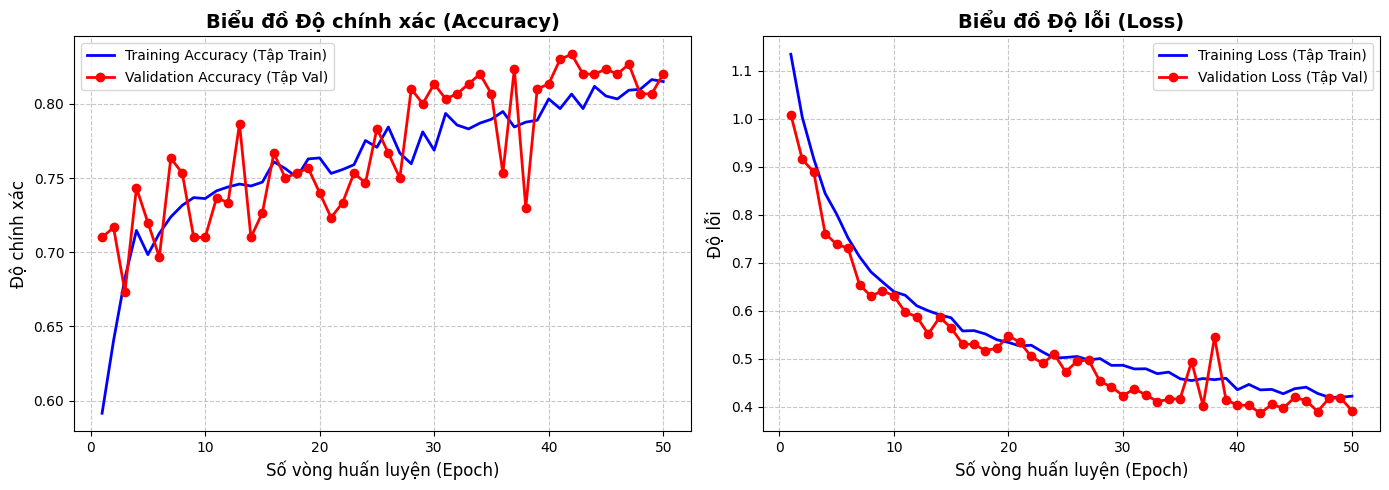

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy (Tập Train)', linewidth=2)
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy (Tập Val)', linewidth=2)
plt.title('Biểu đồ Độ chính xác (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Số vòng huấn luyện (Epoch)', fontsize=12)
plt.ylabel('Độ chính xác', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss (Tập Train)', linewidth=2)
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss (Tập Val)', linewidth=2)
plt.title('Biểu đồ Độ lỗi (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Số vòng huấn luyện (Epoch)', fontsize=12)
plt.ylabel('Độ lỗi', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

Đã tải thành công mô hình!
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST:
                            precision    recall  f1-score   support

Bình thường (Non-Violence)     0.8529    0.7682    0.8084       151
        Bạo lực (Violence)     0.7892    0.8675    0.8265       151

                  accuracy                         0.8179       302
                 macro avg     0.8210    0.8179    0.8174       302
              weighted avg     0.8210    0.8179    0.8174       302



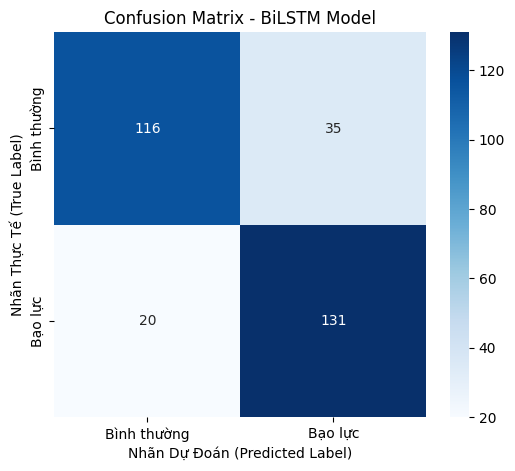

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load lại mô hình tốt nhất đã lưu
model_path = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras'
model = tf.keras.models.load_model(model_path)
print("Đã tải thành công mô hình!")

# 2. Dự đoán xác suất trên tập X_test (X_test đã được chuẩn hóa ở bước trước)
y_pred_prob = model.predict(X_test)
# Chuyển xác suất (> 0.5) thành nhãn nhị phân (0 hoặc 1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Tính và in Báo cáo phân loại (Classification Report)
print("\n" + "="*50)
print("BÁO CÁO ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Bình thường (Non-Violence)', 'Bạo lực (Violence)'], digits=4))

# 4. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường', 'Bạo lực'],
            yticklabels=['Bình thường', 'Bạo lực'])
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.title('Confusion Matrix - BiLSTM Model')
plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# 1. Tự động kiểm tra và nạp file model từ Google Drive
drive_model_path = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras'
local_model_path = 'bilstm_best_model.keras'

model_path = drive_model_path if os.path.exists(drive_model_path) else local_model_path
print(f"-> Đang nạp mô hình từ: {model_path}")
model = tf.keras.models.load_model(model_path)

# 2. Nạp tập Train (để lấy thông số Scale gốc) và tập Test (301 mẫu)
X_train = np.load('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints/train/train_pose.npy')
X_test = np.load('/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/Pose_Keypoints/test/test_pose.npy')[:301]

# 3. Chuẩn hóa X_test theo đúng phân phối của X_train (Z-Score)
N_tr, T, F = X_train.shape
N_te, _, _ = X_test.shape

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F)) # Học mean & std từ tập Train gốc

X_test_scaled = scaler.transform(X_test.reshape(-1, F)).reshape(N_te, T, F)

# 4. Chạy dự đoán lại từ mô hình 81%
y_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()

print("\n=== KẾT QUẢ PHÂN PHỐI XÁC SUẤT CHUẨN ===")
print(f"• Xác suất Min: {y_pred_prob.min():.4f}")
print(f"• Xác suất Max: {y_pred_prob.max():.4f}")
print(f"• Xác suất Trung bình: {y_pred_prob.mean():.4f}")
print("• 10 mẫu đầu tiên:", np.round(y_pred_prob[:10], 4))

-> Đang nạp mô hình từ: /content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras

=== KẾT QUẢ PHÂN PHỐI XÁC SUẤT CHUẨN ===
• Xác suất Min: 0.0030
• Xác suất Max: 0.9625
• Xác suất Trung bình: 0.4952
• 10 mẫu đầu tiên: [0.7734 0.4608 0.1072 0.6325 0.0502 0.7342 0.3929 0.1128 0.7049 0.6548]


• Độ chính xác (Accuracy): 61.79%
• Tổng số mẫu test: 301
• Số mẫu dự đoán SAI: 115 (38.21%)
• False Negatives (Bỏ sót bạo lực - Cần tối thiểu hóa): 53 mẫu
• False Positives (Báo động giả): 62 mẫu

=== BẢNG TÌM NGƯỠNG TỐI ƯU (THRESHOLD TUNING) ===
 Threshold  Precision  Recall (Bắt bạo lực)  F1-Score
       0.1     0.5451                0.9205    0.6847
       0.2     0.5447                0.8874    0.6751
       0.3     0.5665                0.8742    0.6875
       0.4     0.5813                0.7815    0.6667
       0.5     0.6125                0.6490    0.6302
       0.6     0.6434                0.5497    0.5929
       0.7     0.7595                0.3974    0.5217
       0.8     0.7949                0.2053    0.3263
       0.9     0.8333                0.0662    0.1227


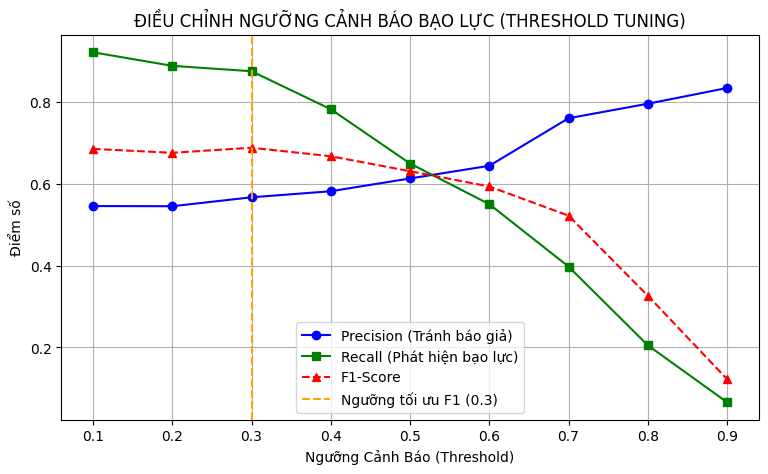

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. Khởi tạo nhãn thực tế từ test_df
y_true = test_df['label_idx'].values[:len(y_pred_prob)].astype(int)

# 2. Đánh giá ở ngưỡng mặc định 0.5
y_pred_05 = (y_pred_prob >= 0.5).astype(int)
acc = accuracy_score(y_true, y_pred_05) * 100

df_results = pd.DataFrame({
    'True_Label': y_true,
    'Pred_Prob': y_pred_prob,
    'Pred_Label_0.5': y_pred_05
})

errors = df_results[df_results['True_Label'] != df_results['Pred_Label_0.5']]
fn = errors[(errors['True_Label'] == 1) & (errors['Pred_Label_0.5'] == 0)]
fp = errors[(errors['True_Label'] == 0) & (errors['Pred_Label_0.5'] == 1)]

print(f"• Độ chính xác (Accuracy): {acc:.2f}%")
print(f"• Tổng số mẫu test: {len(y_true)}")
print(f"• Số mẫu dự đoán SAI: {len(errors)} ({len(errors)/len(y_true)*100:.2f}%)")
print(f"• False Negatives (Bỏ sót bạo lực - Cần tối thiểu hóa): {len(fn)} mẫu")
print(f"• False Positives (Báo động giả): {len(fp)} mẫu")

# 3. Điều chỉnh ngưỡng cảnh báo (Threshold Tuning từ 0.1 đến 0.9)
thresholds = np.arange(0.1, 1.0, 0.1)
records = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    p = precision_score(y_true, y_pred_t, zero_division=0)
    r = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)

    records.append({
        'Threshold': round(t, 1),
        'Precision': round(p, 4),
        'Recall (Bắt bạo lực)': round(r, 4),
        'F1-Score': round(f1, 4)
    })

df_thresh = pd.DataFrame(records)
print("\n=== BẢNG TÌM NGƯỠNG TỐI ƯU (THRESHOLD TUNING) ===")
print(df_thresh.to_string(index=False))

# 4. Vẽ biểu đồ Precision-Recall-F1
plt.figure(figsize=(9, 5))
plt.plot(df_thresh['Threshold'], df_thresh['Precision'], 'b-o', label='Precision (Tránh báo giả)')
plt.plot(df_thresh['Threshold'], df_thresh['Recall (Bắt bạo lực)'], 'g-s', label='Recall (Phát hiện bạo lực)')
plt.plot(df_thresh['Threshold'], df_thresh['F1-Score'], 'r--^', label='F1-Score')

# Tìm ngưỡng có F1-Score cao nhất
best_row = df_thresh.loc[df_thresh['F1-Score'].idxmax()]
best_t = best_row['Threshold']
plt.axvline(x=best_t, color='orange', linestyle='--', label=f'Ngưỡng tối ưu F1 ({best_t})')

plt.title('ĐIỀU CHỈNH NGƯỠNG CẢNH BÁO BẠO LỰC (THRESHOLD TUNING)')
plt.xlabel('Ngưỡng Cảnh Báo (Threshold)')
plt.ylabel('Điểm số')
plt.legend()
plt.grid(True)
plt.show()

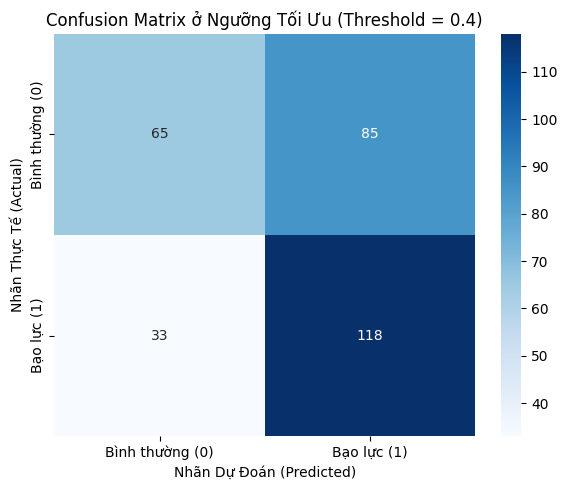

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Áp dụng ngưỡng tối ưu 0.4
y_pred_opt = (y_pred_prob >= 0.4).astype(int)
cm = confusion_matrix(y_true, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường (0)', 'Bạo lực (1)'],
            yticklabels=['Bình thường (0)', 'Bạo lực (1)'])

plt.title('Confusion Matrix ở Ngưỡng Tối Ưu (Threshold = 0.4)')
plt.xlabel('Nhãn Dự Đoán (Predicted)')
plt.ylabel('Nhãn Thực Tế (Actual)')
plt.tight_layout()
plt.show()

In [ ]:
from collections import deque
import cv2
import numpy as np
import tensorflow as tf
import os
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. Load mô hình BiLSTM
model_path = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras'
model = tf.keras.models.load_model(model_path)

# 2. Khởi tạo PoseLandmarker
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)
detector = vision.PoseLandmarker.create_from_options(options)

def extract_keypoints_from_landmarks(landmarks):
    if landmarks:
        pose = []
        for lm in landmarks:
            visibility = getattr(lm, 'visibility', 0.0)
            pose.extend([lm.x, lm.y, lm.z, visibility])
        return np.array(pose, dtype=np.float32)
    else:
        return np.zeros(132, dtype=np.float32)

def calculate_frame_velocity(prev_lm, curr_lm):
    """Tính vận tốc chuyển động ngầm để lọc đứng yên"""
    if prev_lm is None or curr_lm is None:
        return 0.0

    active_joints = [13, 14, 15, 16, 25, 26, 27, 28] # Tay & Chân
    p1 = np.array([[prev_lm[i].x, prev_lm[i].y] for i in active_joints])
    p2 = np.array([[curr_lm[i].x, curr_lm[i].y] for i in active_joints])

    distances = np.linalg.norm(p2 - p1, axis=1)
    return float(np.max(distances))

def draw_pose_landmarks(frame, landmarks, width, height):
    connections = [
        (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
        (11, 23), (12, 24), (23, 24), (23, 25), (24, 26),
        (25, 27), (26, 28), (27, 29), (28, 30), (29, 31), (30, 32)
    ]
    for p1, p2 in connections:
        pt1 = (int(landmarks[p1].x * width), int(landmarks[p1].y * height))
        pt2 = (int(landmarks[p2].x * width), int(landmarks[p2].y * height))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 2)
    for lm in landmarks:
        cx, cy = int(lm.x * width), int(lm.y * height)
        cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

def process_single_video(input_video_path, output_video_path, model, threshold=0.75, velocity_threshold=0.035, frame_stride=2):
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print(f"Không thể mở video: {input_video_path}")
        return

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    if fps == 0: fps = 30

    os.makedirs(os.path.dirname(output_video_path), exist_ok=True)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    sequence = []
    prob_history = deque(maxlen=3)

    label = "BINH THUONG"
    bg_color = (0, 150, 0)
    text_color = (255, 255, 255)

    frame_idx = 0
    prev_landmarks = None
    current_velocity = 0.0

    print(f"\nĐang xử lý: {os.path.basename(input_video_path)} ...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        results = detector.detect(mp_image)

        curr_landmarks = None
        if results.pose_landmarks and len(results.pose_landmarks) > 0:
            curr_landmarks = results.pose_landmarks[0]
            draw_pose_landmarks(frame, curr_landmarks, width, height)

        if prev_landmarks is not None and curr_landmarks is not None:
            current_velocity = calculate_frame_velocity(prev_landmarks, curr_landmarks)

        prev_landmarks = curr_landmarks

        if frame_idx % frame_stride == 0:
            keypoints = extract_keypoints_from_landmarks(curr_landmarks)
            sequence.append(keypoints)
            sequence = sequence[-30:]

            if len(sequence) == 30:
                input_data = np.array(sequence)
                input_data = np.expand_dims(input_data, axis=0)

                # Chuẩn hóa về tâm hông Mid-Hip
                input_data = normalize_pose_to_hip_center(input_data)

                raw_prob = float(model.predict(input_data, verbose=0)[0][0])
                prob_history.append(raw_prob)
                smoothed_prob = np.mean(prob_history)

                # KIỂM TRA ĐIỀU KIỆN: Chỉ bật bạo lực khi vừa có dáng bạo lực VÀ có chuyển động vung đấm/đá
                if smoothed_prob >= threshold and current_velocity >= velocity_threshold:
                    label = "CANH BAO: BAO LUC"
                    bg_color = (0, 0, 200) # Đỏ
                else:
                    label = "BINH THUONG"
                    bg_color = (0, 150, 0) # Xanh

        # Hiển thị duy nhất nhãn "BINH THUONG" hoặc "CANH BAO: BAO LUC"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2

        (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        padding = 8

        cv2.rectangle(frame, (10, 10), (10 + text_w + padding * 2, 10 + text_h + baseline + padding * 2), bg_color, -1)
        cv2.putText(frame, label, (10 + padding, 10 + text_h + padding), font, font_scale, text_color, thickness, cv2.LINE_AA)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"Đã lưu kết quả tại: {output_video_path}")

# --- THỰC THI CHẠY DEMO ---
video_input_path  = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/video_test/vieo.mp4'
video_output_path = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/video_KetQua/KetQua_Video_Fix.mp4'

process_single_video(
    video_input_path,
    video_output_path,
    model,
    threshold=0.75,
    velocity_threshold=0.035,
    frame_stride=2
)


Đang xử lý: vieo.mp4 ...
Đã lưu kết quả tại: /content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/video_KetQua/KetQua_Video_Fix.mp4


In [9]:
from collections import deque
import cv2
import numpy as np
import tensorflow as tf
import os
import subprocess
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import gradio as gr
from google.colab import drive

# 1. Kết nối Drive & Load mô hình
drive.mount('/content/drive', force_remount=True)

model_path = '/content/drive/MyDrive/Đồ án chuyên ngành trí tuệ nhân tạo/bilstm_best_model.keras'
model = tf.keras.models.load_model(model_path)

# 2. Khởi tạo PoseLandmarker
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=2 # Cho phép nhận diện nhiều người để chọn đúng người đang theo dõi
)
detector = vision.PoseLandmarker.create_from_options(options)

def normalize_pose_to_hip_center(sequence_data):
    seq = sequence_data.copy()
    for i in range(len(seq[0])):
        hip_x = (seq[0][i][23*4] + seq[0][i][24*4]) / 2.0
        hip_y = (seq[0][i][23*4 + 1] + seq[0][i][24*4 + 1]) / 2.0
        for j in range(33):
            seq[0][i][j*4] -= hip_x
            seq[0][i][j*4 + 1] -= hip_y
    return seq

def extract_keypoints_from_landmarks(landmarks):
    if landmarks:
        pose = []
        for lm in landmarks:
            visibility = getattr(lm, 'visibility', 0.0)
            pose.extend([lm.x, lm.y, lm.z, visibility])
        return np.array(pose, dtype=np.float32)
    else:
        return np.zeros(132, dtype=np.float32)

def calculate_frame_velocity(prev_lm, curr_lm):
    if prev_lm is None or curr_lm is None:
        return 0.0
    active_joints = [13, 14, 15, 16, 25, 26, 27, 28] # Tay & Chân
    p1 = np.array([[prev_lm[i].x, prev_lm[i].y] for i in active_joints])
    p2 = np.array([[curr_lm[i].x, curr_lm[i].y] for i in active_joints])
    distances = np.linalg.norm(p2 - p1, axis=1)
    return float(np.max(distances))

def get_best_matching_person(all_poses, prev_landmarks):
    """Tìm đúng người đang theo dõi ở frame trước dựa vào tâm hông"""
    if not all_poses:
        return None
    if prev_landmarks is None:
        return all_poses[0]

    prev_hip_x = (prev_landmarks[23].x + prev_landmarks[24].x) / 2.0
    prev_hip_y = (prev_landmarks[23].y + prev_landmarks[24].y) / 2.0

    best_pose = all_poses[0]
    min_dist = float('inf')

    for pose in all_poses:
        curr_hip_x = (pose[23].x + pose[24].x) / 2.0
        curr_hip_y = (pose[23].y + pose[24].y) / 2.0
        dist = np.hypot(curr_hip_x - prev_hip_x, curr_hip_y - prev_hip_y)
        if dist < min_dist:
            min_dist = dist
            best_pose = pose

    return best_pose

def draw_pose_landmarks(frame, landmarks, width, height):
    connections = [
        (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),
        (11, 23), (12, 24), (23, 24), (23, 25), (24, 26),
        (25, 27), (26, 28), (27, 29), (28, 30), (29, 31), (30, 32)
    ]
    for p1, p2 in connections:
        pt1 = (int(landmarks[p1].x * width), int(landmarks[p1].y * height))
        pt2 = (int(landmarks[p2].x * width), int(landmarks[p2].y * height))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 2)
    for lm in landmarks:
        cx, cy = int(lm.x * width), int(lm.y * height)
        cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

# 4. Hàm xử lý Video
def process_video_gradio(input_video_path, threshold=0.50, velocity_threshold=0.02, frame_stride=2):
    if input_video_path is None:
        return None, None

    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        return None, None

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 5 or fps > 120 or np.isnan(fps):
        fps = 30.0

    temp_output_path = "/content/temp_gradio_output.mp4"
    final_output_path = "/content/final_gradio_output.mp4"

    if os.path.exists(temp_output_path): os.remove(temp_output_path)
    if os.path.exists(final_output_path): os.remove(final_output_path)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(temp_output_path, fourcc, fps, (width, height))

    sequence = []
    prob_history = deque(maxlen=2) # Giảm maxlen xuống 2 để phản ứng nhanh hơn

    label = "BINH THUONG"
    bg_color = (0, 150, 0)
    text_color = (255, 255, 255)

    frame_idx = 0
    prev_landmarks = None
    current_velocity = 0.0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        results = detector.detect(mp_image)

        curr_landmarks = None
        if results.pose_landmarks and len(results.pose_landmarks) > 0:
            # Chọn đúng người cố định qua tracking tâm hông
            curr_landmarks = get_best_matching_person(results.pose_landmarks, prev_landmarks)
            draw_pose_landmarks(frame, curr_landmarks, width, height)

        if prev_landmarks is not None and curr_landmarks is not None:
            current_velocity = calculate_frame_velocity(prev_landmarks, curr_landmarks)

        prev_landmarks = curr_landmarks

        if frame_idx % frame_stride == 0:
            keypoints = extract_keypoints_from_landmarks(curr_landmarks)
            sequence.append(keypoints)
            sequence = sequence[-30:]

            if len(sequence) == 30:
                input_data = np.array(sequence)
                input_data = np.expand_dims(input_data, axis=0)

                input_data = normalize_pose_to_hip_center(input_data)

                raw_prob = float(model.predict(input_data, verbose=0)[0][0])
                prob_history.append(raw_prob)
                smoothed_prob = np.mean(prob_history)

                # Ngưỡng phân loại được đưa về chuẩn 0.50
                if smoothed_prob >= threshold and current_velocity >= velocity_threshold:
                    label = f"CANH BAO: BAO LUC ({smoothed_prob*100:.1f}%)"
                    bg_color = (0, 0, 200)
                else:
                    label = f"BINH THUONG (Bao luc: {smoothed_prob*100:.1f}%)"
                    bg_color = (0, 150, 0)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2
        (text_w, text_h), baseline = cv2.getTextSize(label, font, font_scale, thickness)
        padding = 8

        cv2.rectangle(frame, (10, 10), (10 + text_w + padding * 2, 10 + text_h + baseline + padding * 2), bg_color, -1)
        cv2.putText(frame, label, (10 + padding, 10 + text_h + padding), font, font_scale, text_color, thickness, cv2.LINE_AA)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()

    cmd = [
        "ffmpeg", "-y",
        "-i", temp_output_path,
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        "-preset", "ultrafast",
        "-movflags", "+faststart",
        "-an",
        final_output_path
    ]
    subprocess.run(cmd, check=True)

    return final_output_path, final_output_path

# 5. Giao diện Gradio
custom_css = """
.fit-video video {
    object-fit: contain !important;
    max-height: 400px !important;
    width: 100% !important;
}
"""

with gr.Blocks(title="Hệ Thống Nhận Diện Bạo Lực", css=custom_css) as demo:
    gr.Markdown("# 🎥 Hệ Thống Phát Hiện Hành Vi Bạo Lực")

    with gr.Row():
        with gr.Column():
            video_input = gr.Video(label="Tải Video Vào", elem_classes=["fit-video"], height=400)
            btn_process = gr.Button("🔍 Phân Tích Video", variant="primary")

        with gr.Column():
            video_output = gr.Video(label="Xem Trực Tiếp Trên Web", elem_classes=["fit-video"], height=400)
            file_output = gr.File(label="📥 Tải Video Kết Quả Về Máy")

    btn_process.click(
        fn=process_video_gradio,
        inputs=video_input,
        outputs=[video_output, file_output]
    )

demo.launch(share=True, debug=True)

Mounted at /content/drive


/tmp/ipykernel_2493/43405019.py:210: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Hệ Thống Nhận Diện Bạo Lực", css=custom_css) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b131b2c0a8e20af8db.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b131b2c0a8e20af8db.gradio.live
